<a href="https://colab.research.google.com/github/vsmacedo-datafinance/Challenge_Locaweb_FIAP_2026/blob/main/notebooks/07_Tendencias_Operacionais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Projeto Chronos** | CHALLENGE LOCAWEB 2026

**Integrantes:**
* Bruno Rosa — RM563779
* Danilo Alves — RM564109
* Enzo Cremaschi — RM562058
* Vinícius Macedo — RM561911

# 07 — Desafio 2: Tendências Operacionais (volume, agrupamentos críticos e recorrência)

**O que o enunciado pede e este notebook responde:**

| Item oficial | Onde é respondido |
|---|---|
| Objetivo 2: "identificar tendências por prioridade, com **P2 e P3 obrigatórias**" | Parte 2 (volume semanal por prioridade, elegível e bruto) |
| Desafio 1 (analítico): "sazonalidade, **agrupamentos críticos e recorrência**" | Partes 3 e 4 (decomposição do crescimento; top produtos/categorias/templates/ativos) |
| Desafio 4: "**quais fatores mais influenciam o aumento de incidentes**" | Parte 3 — esta é a pergunta sobre VOLUME; o notebook 06 (SHAP) responde a pergunta sobre RISCO por chamado |
| Objetivo 3: "projetar impacto nos KPIs com tendência diária de volume e **de perda de OLA**" | Parte 5 (violações semanais e atingimento acumulado vs. metas oficiais) |

**Decisão de leitura:** as últimas semanas da base podem estar censuradas em `Entrou para KPI?` (ver notebook 04, seção 0.5). Aqui a censura é detectada com a mesma função e as semanas afetadas ficam **sombreadas nos gráficos e fora das estatísticas de crescimento** — não somem, mas não viram conclusão.

**Conclusão:** gerada por código a partir dos números desta execução (Parte 7), sem texto-modelo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/cronos_project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    setup_logging, PROJECT_PATHS, load_parquet_layer,
    proporcao_elegivel_por_semana, detectar_censura_elegibilidade,
    checar_faixa_kpi, FAIXAS_VOLUME_ANUAL_P2, FAIXAS_VOLUME_ANUAL_P3,
    FAIXAS_OLA_QUEBRADO_ANUAL_P2, FAIXAS_OLA_QUEBRADO_ANUAL_P3,
)

logger = setup_logging('tendencias_desafio2')
JANELA_SEMANAS = 8   # comparação "últimas 8 semanas válidas" vs. "8 semanas anteriores"

---
## PARTE 1 — Carga e detecção de censura

In [ ]:
df = load_parquet_layer(PROJECT_PATHS.gold / 'gold_chamados_risco.parquet', logger=logger)
df['Aberto'] = pd.to_datetime(df['Aberto'])
df['semana'] = df['Aberto'].dt.to_period('W').dt.start_time
df['elegivel'] = df['Entrou para KPI?'].eq('SIM')
df['violou'] = df['KPI Violado?'].eq('SIM') & df['elegivel']
df['origem'] = df['Aberto por'].fillna('Desconhecida')

gold_tendencias = load_parquet_layer(PROJECT_PATHS.gold / 'gold_tendencias_macro.parquet', logger=logger)
gold_tendencias['semana'] = pd.to_datetime(gold_tendencias['semana'])

# semanas completas: a primeira e a última semana podem ter menos de 7 dias
dias_por_semana = df.groupby('semana')['Aberto'].agg(lambda s: s.dt.normalize().nunique())
semanas_completas = dias_por_semana[dias_por_semana >= 7].index
logger.info('%d semanas na base, %d completas (7 dias).', len(dias_por_semana), len(semanas_completas))

prop_elegivel = proporcao_elegivel_por_semana(df, time_col='Aberto', flag_col='Entrou para KPI?')
diag = detectar_censura_elegibilidade(prop_elegivel, semanas_referencia=20, semanas_finais_max=4, limiar_relativo=0.7)
semana_corte = diag['data_corte']
if diag['censurado']:
    logger.warning('Censura em Entrou para KPI?: %d semana(s) finais abaixo de 70%% da referência (%.3f). Estatísticas de crescimento usam semanas < %s.',
                   diag['n_semanas_censuradas'], diag['referencia'], semana_corte.date())
else:
    logger.info('Sem censura detectada (referência %.3f) — todas as semanas completas entram nas estatísticas.', diag['referencia'])

semanas_validas = [s for s in semanas_completas if semana_corte is None or s < semana_corte]
janela_recente = semanas_validas[-JANELA_SEMANAS:]
janela_anterior = semanas_validas[-2 * JANELA_SEMANAS:-JANELA_SEMANAS]
logger.info('Janela recente: %s a %s | anterior: %s a %s', janela_recente[0].date(), janela_recente[-1].date(), janela_anterior[0].date(), janela_anterior[-1].date())


def sombrear_censura(ax):
    if semana_corte is not None:
        ax.axvspan(semana_corte, df['semana'].max() + pd.Timedelta(days=7), color='grey', alpha=0.15, label='semanas censuradas (flag KPI)')

2026-09-10 21:35:04 | INFO     | tendencias_desafio2 | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:tendencias_desafio2:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


2026-09-10 21:35:05 | INFO     | tendencias_desafio2 | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_tendencias_macro.parquet: 8036 linhas x 8 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:tendencias_desafio2:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_tendencias_macro.parquet: 8036 linhas x 8 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


2026-09-10 21:35:05 | INFO     | tendencias_desafio2 | 53 semanas na base, 51 completas (7 dias).


INFO:tendencias_desafio2:53 semanas na base, 51 completas (7 dias).


2026-09-10 21:35:05 | WARNING  | tendencias_desafio2 | Censura em Entrou para KPI?: 4 semana(s) finais abaixo de 70% da referência (0.099). Estatísticas de crescimento usam semanas < 2025-12-08.


2026-09-10 21:35:05 | INFO     | tendencias_desafio2 | Janela recente: 2025-10-13 a 2025-12-01 | anterior: 2025-08-18 a 2025-10-06


INFO:tendencias_desafio2:Janela recente: 2025-10-13 a 2025-12-01 | anterior: 2025-08-18 a 2025-10-06


---
## PARTE 2 — Tendência de volume por prioridade (P2 e P3 obrigatórias)

Duas leituras lado a lado, porque contam histórias diferentes: o **bruto** é a carga que chega na operação (inclui alarmes de monitoramento não elegíveis); o **elegível** é o que a Locaweb mede no KPI.

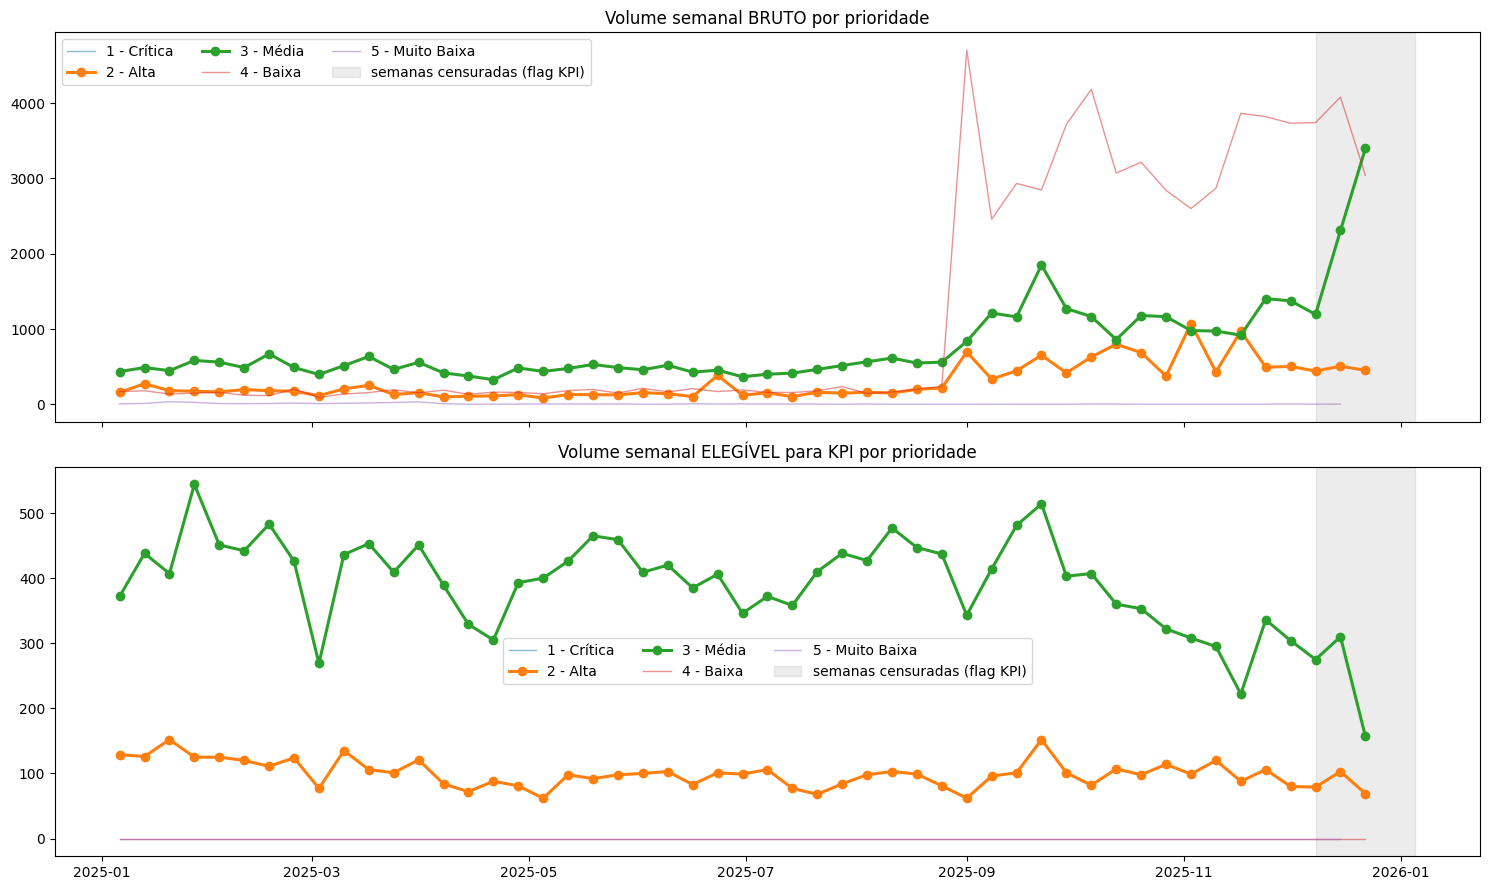

,media_semanal_bruto,inclinacao_bruto_por_semana,media_semanal_elegivel,inclinacao_elegivel_por_semana
Prioridade,,,,
1 - Crítica,1.00,NaN,0.00,NaN
2 - Alta,291.10,11.60,100.73,-0.45
3 - Média,685.52,17.50,398.77,-1.80
4 - Baixa,1094.71,82.76,0.00,0.00
5 - Muito Baixa,8.11,-0.50,0.00,0.00


In [ ]:
vol_semana = df.groupby(['semana', 'Prioridade']).agg(bruto=('Número', 'count'), elegivel=('elegivel', 'sum'), violacoes=('violou', 'sum')).reset_index()
vol_semana = vol_semana[vol_semana['semana'].isin(semanas_completas)]

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
for ax, coluna, titulo in [(axes[0], 'bruto', 'Volume semanal BRUTO por prioridade'), (axes[1], 'elegivel', 'Volume semanal ELEGÍVEL para KPI por prioridade')]:
    for prio, g in vol_semana.groupby('Prioridade'):
        destaque = prio in ('2 - Alta', '3 - Média')
        ax.plot(g['semana'], g[coluna], marker='o' if destaque else None, linewidth=2.2 if destaque else 1, alpha=1 if destaque else 0.5, label=prio)
    sombrear_censura(ax)
    ax.set_title(titulo); ax.legend(ncol=3)
plt.tight_layout(); plt.show()

# tendência linear simples (chamados/semana por semana) nas semanas válidas, por prioridade — P2 e P3 em destaque
def inclinacao(g, coluna):
    g = g[g['semana'].isin(semanas_validas)].sort_values('semana')
    if len(g) < 3:
        return np.nan
    x = np.arange(len(g))
    return float(np.polyfit(x, g[coluna].values, 1)[0])

tendencia_prioridade = vol_semana.groupby('Prioridade').apply(lambda g: pd.Series({
    'media_semanal_bruto': g.loc[g['semana'].isin(semanas_validas), 'bruto'].mean(),
    'inclinacao_bruto_por_semana': inclinacao(g, 'bruto'),
    'media_semanal_elegivel': g.loc[g['semana'].isin(semanas_validas), 'elegivel'].mean(),
    'inclinacao_elegivel_por_semana': inclinacao(g, 'elegivel'),
}), include_groups=False).round(2)
display(tendencia_prioridade)

---
## PARTE 3 — Quais fatores mais influenciam o aumento de incidentes?

Decomposição do crescimento: volume médio semanal nas últimas 8 semanas válidas menos o das 8 anteriores, quebrado por **origem** (`Aberto por`), **elegibilidade** e **prioridade**. A coluna `participacao_no_crescimento_pct` diz quanto do aumento total vem de cada fatia — se 90% vier de "Monitoramento / não elegível", o "aumento de incidentes" é ruído de alarme, não carga operacional real.

In [ ]:
def media_semanal(mask_semanas, chaves):
    d = df[df['semana'].isin(mask_semanas)]
    return d.groupby(chaves, dropna=False)['Número'].count() / len(mask_semanas)


def decompor_crescimento(chaves):
    recente = media_semanal(janela_recente, chaves).rename('media_recente')
    anterior = media_semanal(janela_anterior, chaves).rename('media_anterior')
    out = pd.concat([anterior, recente], axis=1).fillna(0)
    out['delta_semanal'] = out['media_recente'] - out['media_anterior']
    out['variacao_pct'] = np.where(out['media_anterior'] > 0, out['delta_semanal'] / out['media_anterior'] * 100, np.nan)
    delta_total = out['delta_semanal'].sum()
    out['participacao_no_crescimento_pct'] = (out['delta_semanal'] / delta_total * 100) if delta_total != 0 else np.nan
    return out.round(2).sort_values('delta_semanal', ascending=False)


crescimento_total = float(df[df['semana'].isin(janela_recente)].shape[0] / len(janela_recente) - df[df['semana'].isin(janela_anterior)].shape[0] / len(janela_anterior))
logger.info('Crescimento do volume total: %+.1f chamados/semana entre as duas janelas.', crescimento_total)

crescimento_origem_elegivel = decompor_crescimento(['origem', 'elegivel'])
crescimento_prioridade = decompor_crescimento(['Prioridade'])
crescimento_prioridade_elegivel = decompor_crescimento(['Prioridade', 'elegivel'])

print('--- Por origem × elegibilidade ---'); display(crescimento_origem_elegivel)
print('--- Por prioridade ---'); display(crescimento_prioridade)
print('--- Por prioridade × elegibilidade ---'); display(crescimento_prioridade_elegivel)

fatia_dominante = crescimento_origem_elegivel.index[0]
participacao_dominante = float(crescimento_origem_elegivel.iloc[0]['participacao_no_crescimento_pct'])

2026-09-10 21:35:06 | INFO     | tendencias_desafio2 | Crescimento do volume total: +840.0 chamados/semana entre as duas janelas.


INFO:tendencias_desafio2:Crescimento do volume total: +840.0 chamados/semana entre as duas janelas.


--- Por origem × elegibilidade ---


,,media_anterior,media_recente,delta_semanal,variacao_pct,participacao_no_crescimento_pct
origem,elegivel,,,,,
Monitoramento,False,3625.75,4576.50,950.75,26.22,113.18
Manual,False,31.62,34.38,2.75,8.70,0.33
Monitoramento,True,203.00,173.38,-29.62,-14.59,-3.53
Manual,True,324.50,240.62,-83.88,-25.85,-9.99


--- Por prioridade ---


,media_anterior,media_recente,delta_semanal,variacao_pct,participacao_no_crescimento_pct
Prioridade,,,,,
4 - Baixa,2659.88,3251.25,591.38,22.23,70.40
2 - Alta,448.75,666.25,217.50,48.47,25.89
3 - Média,1075.25,1106.25,31.00,2.88,3.69
5 - Muito Baixa,1.00,1.12,0.12,12.50,0.01


--- Por prioridade × elegibilidade ---


,,media_anterior,media_recente,delta_semanal,variacao_pct,participacao_no_crescimento_pct
Prioridade,elegivel,,,,,
4 - Baixa,False,2659.88,3251.25,591.38,22.23,70.40
2 - Alta,False,352.00,564.75,212.75,60.44,25.33
3 - Média,False,644.50,793.75,149.25,23.16,17.77
2 - Alta,True,96.75,101.50,4.75,4.91,0.57
5 - Muito Baixa,False,1.00,1.12,0.12,12.50,0.01
3 - Média,True,430.75,312.50,-118.25,-27.45,-14.08


---
## PARTE 4 — Agrupamentos críticos e recorrência

Mesma janela de comparação, agora para achar **onde** o crescimento se concentra: produtos, categorias, templates de descrição e itens de configuração (ativos) com maior aumento absoluto de chamados por semana. Recorrência = ativos que aparecem repetidamente; a coluna `n_chamados_recente` mostra a carga absoluta recente, não só a variação.

In [ ]:
def top_crescimento(coluna, top_n=10, min_recente=10):
    d_rec = df[df['semana'].isin(janela_recente)]
    d_ant = df[df['semana'].isin(janela_anterior)]
    rec = d_rec.groupby(coluna, dropna=True)['Número'].count().rename('n_chamados_recente')
    ant = d_ant.groupby(coluna, dropna=True)['Número'].count().rename('n_chamados_anterior')
    out = pd.concat([ant, rec], axis=1).fillna(0)
    out['delta_semanal'] = (out['n_chamados_recente'] - out['n_chamados_anterior']) / JANELA_SEMANAS
    out['pct_elegivel_recente'] = d_rec.groupby(coluna)['elegivel'].mean().reindex(out.index).fillna(0) * 100
    out['violacoes_recente'] = d_rec.groupby(coluna)['violou'].sum().reindex(out.index).fillna(0).astype(int)
    out = out[out['n_chamados_recente'] >= min_recente]
    return out.sort_values('delta_semanal', ascending=False).head(top_n).round(2)


tops_crescimento = {}
for coluna in ['Produto', 'Categoria', 'descricao_limpa', 'Item de configuração', 'Grupo designado']:
    if coluna in df.columns:
        tops_crescimento[coluna] = top_crescimento(coluna)
        print(f'--- Maior crescimento por {coluna} (últimas {JANELA_SEMANAS} semanas válidas vs. {JANELA_SEMANAS} anteriores) ---')
        display(tops_crescimento[coluna])

# recorrência: ativos com mais chamados na janela recente e quantas semanas distintas aparecem
if 'Item de configuração' in df.columns:
    d_rec = df[df['semana'].isin(janela_recente)]
    recorrencia_ativos = d_rec.groupby('Item de configuração').agg(
        n_chamados=('Número', 'count'), semanas_com_chamado=('semana', 'nunique'), pct_elegivel=('elegivel', 'mean'), violacoes=('violou', 'sum')
    ).sort_values('n_chamados', ascending=False).head(15)
    recorrencia_ativos['pct_elegivel'] = (recorrencia_ativos['pct_elegivel'] * 100).round(1)
    print('--- Ativos mais recorrentes na janela recente ---'); display(recorrencia_ativos)

--- Maior crescimento por Produto (últimas 8 semanas válidas vs. 8 anteriores) ---


,n_chamados_anterior,n_chamados_recente,delta_semanal,pct_elegivel_recente,violacoes_recente
Produto,,,,,
lsaa,103.0,205.0,12.75,50.24,2
khvp,16.0,36.0,2.50,88.89,0
lvps,78.0,98.0,2.50,84.69,0
lsd0,13.0,28.0,1.88,75.00,0
lgoa,40.0,52.0,1.50,98.08,0
lema,1.0,11.0,1.25,100.00,0
lexc,30.0,35.0,0.62,80.00,3
lsg2,38.0,40.0,0.25,62.50,0
lwpl,21.0,21.0,0.00,71.43,0


--- Maior crescimento por Categoria (últimas 8 semanas válidas vs. 8 anteriores) ---


,n_chamados_anterior,n_chamados_recente,delta_semanal,pct_elegivel_recente,violacoes_recente
Categoria,,,,,
cat138,115.0,237.0,15.25,10.55,0
cat71,1555.0,1657.0,12.75,36.51,1
cat126,6.0,49.0,5.38,14.29,0
cat103,69.0,112.0,5.38,95.54,0
cat43,19.0,50.0,3.88,42.00,0
cat35,48.0,76.0,3.50,40.79,1
cat57,4.0,26.0,2.75,100.00,0
cat107,5.0,27.0,2.75,92.59,0
cat74,34.0,54.0,2.50,85.19,0


--- Maior crescimento por descricao_limpa (últimas 8 semanas válidas vs. 8 anteriores) ---


...

,n_chamados_anterior,n_chamados_recente,delta_semanal,pct_elegivel_recente,violacoes_recente
Item de configuração,,,,,
IC00008,812.0,2991.0,272.38,0.00,0
IC00019,932.0,3098.0,270.75,0.00,0
IC00002,665.0,1675.0,126.25,0.00,0
IC00014,1970.0,2898.0,116.00,0.00,0
IC00004,93.0,684.0,73.88,0.44,0
IC03673,1.0,546.0,68.12,0.00,0
IC00901,84.0,485.0,50.12,0.00,0
IC00032,190.0,417.0,28.38,0.00,0
IC00009,27.0,202.0,21.88,0.99,0


--- Maior crescimento por Grupo designado (últimas 8 semanas válidas vs. 8 anteriores) ---


,n_chamados_anterior,n_chamados_recente,delta_semanal,pct_elegivel_recente,violacoes_recente
Grupo designado,,,,,
Team14,27441.0,35157,964.50,3.67,1
Team03,264.0,337,9.12,16.32,0
Team04,23.0,55,4.00,0.00,0
Team17,105.0,135,3.75,67.41,0
Team07,30.0,35,0.62,88.57,4
Team08,13.0,13,0.00,61.54,0
Team01,50.0,48,-0.25,12.50,0
Team16,76.0,38,-4.75,47.37,0
Team02,142.0,87,-6.88,31.03,0


--- Ativos mais recorrentes na janela recente ---


,n_chamados,semanas_com_chamado,pct_elegivel,violacoes
Item de configuração,,,,
IC00019,3098,8,0.0,0
IC00008,2991,8,0.0,0
IC00014,2898,8,0.0,0
IC00002,1675,8,0.0,0
IC00004,684,8,0.4,0
IC03673,546,3,0.0,0
IC00901,485,7,0.0,0
IC00032,417,8,0.0,0
IC00100,276,8,0.0,0


---
## PARTE 5 — Tendência de perda de OLA e atingimento acumulado

Violações semanais por prioridade (P2 e P3, as únicas com meta oficial) e o acumulado do ano contra a faixa oficial do Dicionário de Dados v2. O atingimento é calculado sobre o realizado até a última semana válida; a coluna `ritmo_anualizado` extrapola o ritmo das últimas 8 semanas — é leitura de direção, não previsão (a previsão D+1/D+7 de OLA está no notebook 04, Parte 9b).

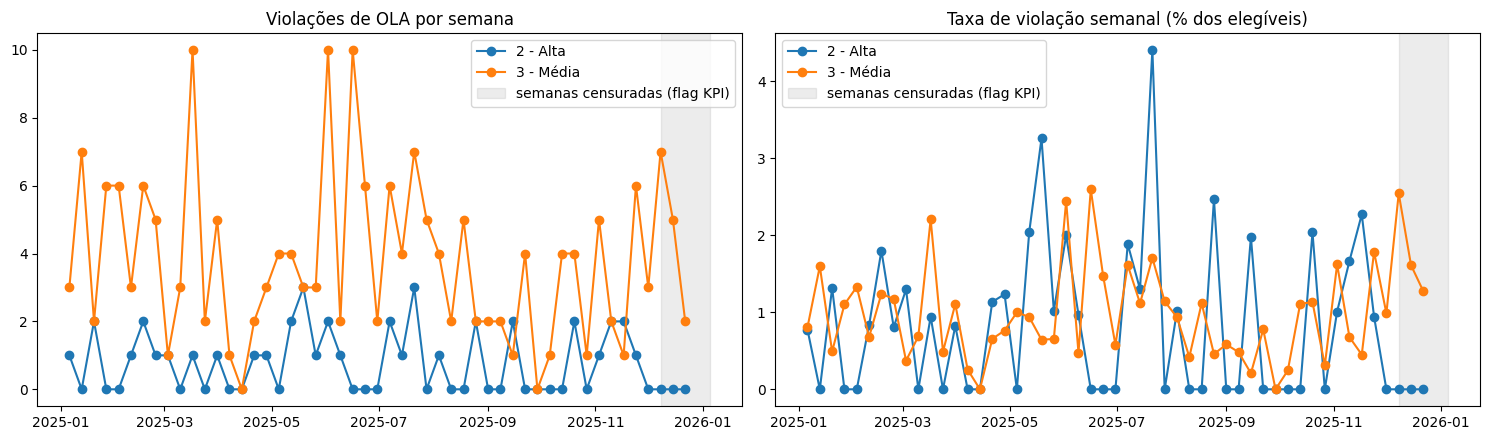

,prioridade,semanas_validas,volume_elegivel_acumulado,atingimento_volume_%,ola_quebrado_acumulado,atingimento_ola_%,ritmo_anualizado_ola,atingimento_ola_no_ritmo_recente_%,taxa_violacao_recente_%
0,2 - Alta,48,4835,125,40,75,52,50,0.99
1,3 - Média,48,19141,150,180,150,169,150,1.04


In [ ]:
ola_semana = vol_semana[vol_semana['Prioridade'].isin(['2 - Alta', '3 - Média'])].copy()
ola_semana['taxa_violacao_pct'] = np.where(ola_semana['elegivel'] > 0, ola_semana['violacoes'] / ola_semana['elegivel'] * 100, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for prio, g in ola_semana.groupby('Prioridade'):
    axes[0].plot(g['semana'], g['violacoes'], marker='o', label=prio)
    axes[1].plot(g['semana'], g['taxa_violacao_pct'], marker='o', label=prio)
for ax, t in zip(axes, ['Violações de OLA por semana', 'Taxa de violação semanal (% dos elegíveis)']):
    sombrear_censura(ax); ax.set_title(t); ax.legend()
plt.tight_layout(); plt.show()

FAIXAS = {'2 - Alta': (FAIXAS_VOLUME_ANUAL_P2, FAIXAS_OLA_QUEBRADO_ANUAL_P2), '3 - Média': (FAIXAS_VOLUME_ANUAL_P3, FAIXAS_OLA_QUEBRADO_ANUAL_P3)}
linhas = []
for prio, (faixa_vol, faixa_ola) in FAIXAS.items():
    g = ola_semana[ola_semana['Prioridade'] == prio]
    g_valido = g[g['semana'].isin(semanas_validas)]
    g_rec = g[g['semana'].isin(janela_recente)]
    vol_acum, ola_acum = int(g_valido['elegivel'].sum()), int(g_valido['violacoes'].sum())
    linhas.append({
        'prioridade': prio, 'semanas_validas': len(g_valido),
        'volume_elegivel_acumulado': vol_acum, 'atingimento_volume_%': checar_faixa_kpi(vol_acum, faixa_vol),
        'ola_quebrado_acumulado': ola_acum, 'atingimento_ola_%': checar_faixa_kpi(ola_acum, faixa_ola),
        'ritmo_anualizado_ola': int(round(g_rec['violacoes'].mean() * 52)),
        'atingimento_ola_no_ritmo_recente_%': checar_faixa_kpi(g_rec['violacoes'].mean() * 52, faixa_ola),
        'taxa_violacao_recente_%': round(g_rec['violacoes'].sum() / max(g_rec['elegivel'].sum(), 1) * 100, 2),
    })
atingimento_kpi = pd.DataFrame(linhas)
display(atingimento_kpi)

---
## PARTE 6 — Cobertura de categorização ao longo do ano

Quanto do que chega tem `Produto`/`Categoria` preenchidos. Importa para o Desafio 2 porque toda conclusão "por produto" ou "por categoria" cobre só essa fração — e ela cai quando o monitoramento cresce.

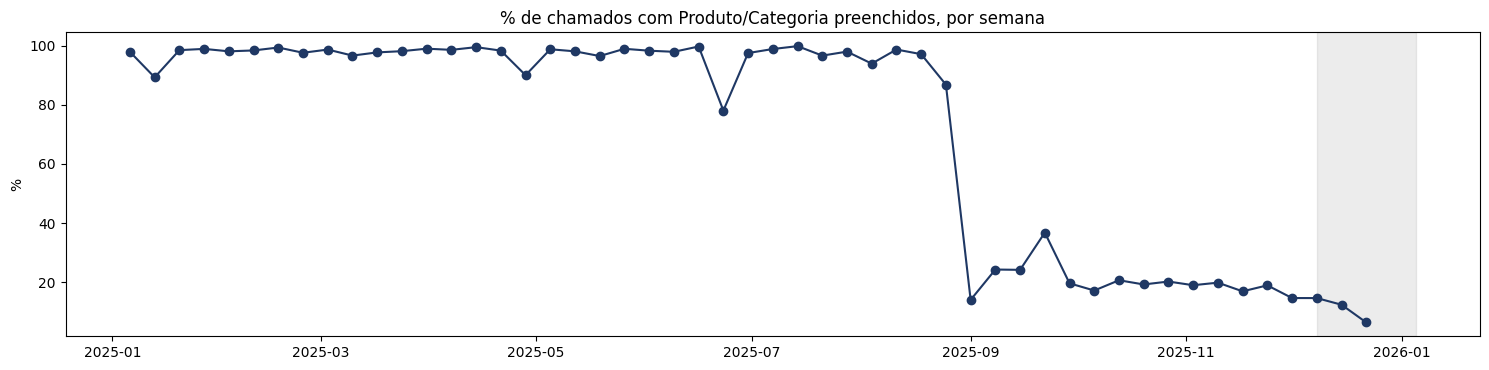

2026-09-10 21:35:08 | INFO     | tendencias_desafio2 | Cobertura de categorização: 18.7% (recente) vs. 40.0% (anterior).


INFO:tendencias_desafio2:Cobertura de categorização: 18.7% (recente) vs. 40.0% (anterior).


In [ ]:
cobertura = df.groupby('semana')['flag_categorizado'].mean().mul(100).rename('pct_categorizado')
cobertura = cobertura[cobertura.index.isin(semanas_completas)]
fig, ax = plt.subplots(figsize=(15, 3.8))
ax.plot(cobertura.index, cobertura.values, marker='o', color='#1F3864')
sombrear_censura(ax)
ax.set_title('% de chamados com Produto/Categoria preenchidos, por semana'); ax.set_ylabel('%')
plt.tight_layout(); plt.show()
cobertura_recente = float(cobertura[cobertura.index.isin(janela_recente)].mean())
cobertura_anterior = float(cobertura[cobertura.index.isin(janela_anterior)].mean())
logger.info('Cobertura de categorização: %.1f%% (recente) vs. %.1f%% (anterior).', cobertura_recente, cobertura_anterior)

---
## PARTE 7 — Conclusão gerada a partir dos números

A célula abaixo escreve a resposta às perguntas do enunciado com os valores desta execução. Depois de rodar, **leia e complemente com a interpretação de negócio** (o código diz *o quê* cresceu; *por quê* é conversa com a operação).

In [ ]:
def fmt_indice(idx):
    return ' / '.join(str(x) if not isinstance(x, (bool, np.bool_)) else ('elegível' if x else 'não elegível') for x in (idx if isinstance(idx, tuple) else (idx,)))


top_prod = tops_crescimento.get('Produto', pd.DataFrame())
top_tpl = tops_crescimento.get('descricao_limpa', pd.DataFrame())
top_ativo = tops_crescimento.get('Item de configuração', pd.DataFrame())
p2 = atingimento_kpi.set_index('prioridade').loc['2 - Alta']
p3 = atingimento_kpi.set_index('prioridade').loc['3 - Média']

conclusao = f'''
**Janela analisada:** {janela_recente[0].date()} a {janela_recente[-1].date() + pd.Timedelta(days=6)} (últimas {JANELA_SEMANAS} semanas válidas) contra {janela_anterior[0].date()} a {janela_anterior[-1].date() + pd.Timedelta(days=6)}. {f"Semanas a partir de {semana_corte.date()} ficaram FORA das estatísticas por censura em `Entrou para KPI?` ({diag['n_semanas_censuradas']} semana(s))." if semana_corte is not None else "Nenhuma semana descartada por censura."}

**1. O volume está aumentando? Onde?** O total de chamados variou {crescimento_total:+.1f}/semana entre as duas janelas. Por prioridade, {', '.join(f"{p} {r.delta_semanal:+.1f}/sem ({r.variacao_pct:+.0f}%)" for p, r in crescimento_prioridade.iterrows())}. Nas prioridades obrigatórias, P2 tem inclinação de {tendencia_prioridade.loc['2 - Alta', 'inclinacao_bruto_por_semana']:+.2f} chamados/semana² no bruto e {tendencia_prioridade.loc['2 - Alta', 'inclinacao_elegivel_por_semana']:+.2f} no elegível; P3, {tendencia_prioridade.loc['3 - Média', 'inclinacao_bruto_por_semana']:+.2f} e {tendencia_prioridade.loc['3 - Média', 'inclinacao_elegivel_por_semana']:+.2f}.

**2. Quais fatores mais influenciam o aumento de incidentes?** A fatia que mais explica a variação é **{fmt_indice(fatia_dominante)}**, com {participacao_dominante:.0f}% do crescimento total ({crescimento_origem_elegivel.iloc[0]['media_anterior']:.0f} → {crescimento_origem_elegivel.iloc[0]['media_recente']:.0f} chamados/semana). Leitura: {"o aumento é majoritariamente carga de alarme automático NÃO elegível para KPI — pressão sobre a triagem, não sobre o OLA" if (isinstance(fatia_dominante, tuple) and fatia_dominante[0] == 'Monitoramento' and fatia_dominante[1] == False) else "o aumento atinge a base medida pelo KPI e merece ação direta na operação"}. Cobertura de categorização {'caiu' if cobertura_recente < cobertura_anterior else 'subiu'} de {cobertura_anterior:.1f}% para {cobertura_recente:.1f}%, o que limita a leitura por produto/categoria a essa fração.

**3. Agrupamentos críticos e recorrência.** {f"Produtos com maior crescimento: {', '.join(f'{i} ({r.delta_semanal:+.1f}/sem, {int(r.violacoes_recente)} violações)' for i, r in top_prod.head(3).iterrows())}." if len(top_prod) else ""} {f"Templates de descrição: {', '.join(f'"{str(i)[:40]}" ({r.delta_semanal:+.1f}/sem)' for i, r in top_tpl.head(3).iterrows())}." if len(top_tpl) else ""} {f"Ativos com maior crescimento: {', '.join(f'{i} ({int(r.n_chamados_recente)} chamados recentes)' for i, r in top_ativo.head(3).iterrows())}." if len(top_ativo) else ""}

**4. Impacto no KPI (P2 e P3).** Acumulado do ano: P2 {int(p2['ola_quebrado_acumulado'])} OLAs quebrados ({p2['atingimento_ola_%']}% de atingimento) e P3 {int(p3['ola_quebrado_acumulado'])} ({p3['atingimento_ola_%']}%). Se o ritmo das últimas {JANELA_SEMANAS} semanas se mantivesse, P2 fecharia em {int(p2['ritmo_anualizado_ola'])} ({p2['atingimento_ola_no_ritmo_recente_%']}%) e P3 em {int(p3['ritmo_anualizado_ola'])} ({p3['atingimento_ola_no_ritmo_recente_%']}%). Taxa de violação recente: P2 {p2['taxa_violacao_recente_%']}%, P3 {p3['taxa_violacao_recente_%']}%.

**Recomendação para a operação (a validar com o mentor):** {"reduzir ruído de alarme na origem (regras de monitoramento) antes de escalar equipe — o crescimento não está no universo medido" if participacao_dominante > 50 and isinstance(fatia_dominante, tuple) and fatia_dominante[1] == False else "reforçar a capacidade nas filas/produtos listados na Parte 4, porque o crescimento chega ao universo medido pelo KPI"}.
'''.strip()

from IPython.display import Markdown
display(Markdown(conclusao))

**Janela analisada:** 2025-10-13 a 2025-12-07 (últimas 8 semanas válidas) contra 2025-08-18 a 2025-10-12. Semanas a partir de 2025-12-08 ficaram FORA das estatísticas por censura em `Entrou para KPI?` (4 semana(s)).

**1. O volume está aumentando? Onde?** O total de chamados variou +840.0/semana entre as duas janelas. Por prioridade, 4 - Baixa +591.4/sem (+22%), 2 - Alta +217.5/sem (+48%), 3 - Média +31.0/sem (+3%), 5 - Muito Baixa +0.1/sem (+12%). Nas prioridades obrigatórias, P2 tem inclinação de +11.60 chamados/semana² no bruto e -0.45 no elegível; P3, +17.50 e -1.80.

**2. Quais fatores mais influenciam o aumento de incidentes?** A fatia que mais explica a variação é **Monitoramento / não elegível**, com 113% do crescimento total (3626 → 4576 chamados/semana). Leitura: o aumento é majoritariamente carga de alarme automático NÃO elegível para KPI — pressão sobre a triagem, não sobre o OLA. Cobertura de categorização caiu de 40.0% para 18.7%, o que limita a leitura por produto/categoria a essa fração.

**3. Agrupamentos críticos e recorrência.** Produtos com maior crescimento: lsaa (+12.8/sem, 2 violações), khvp (+2.5/sem, 0 violações), lvps (+2.5/sem, 0 violações). Templates de descrição: "problem check application monitoring" (+311.9/sem), "problem check application monitoring vip" (+264.4/sem), "problem lack of free swap space 40m 5" (+169.8/sem). Ativos com maior crescimento: IC00008 (2991 chamados recentes), IC00019 (3098 chamados recentes), IC00002 (1675 chamados recentes).

**4. Impacto no KPI (P2 e P3).** Acumulado do ano: P2 40 OLAs quebrados (75.0% de atingimento) e P3 180 (150.0%). Se o ritmo das últimas 8 semanas se mantivesse, P2 fecharia em 52 (50.0%) e P3 em 169 (150.0%). Taxa de violação recente: P2 0.99%, P3 1.04%.

**Recomendação para a operação (a validar com o mentor):** reduzir ruído de alarme na origem (regras de monitoramento) antes de escalar equipe — o crescimento não está no universo medido.

---
## PARTE 8 — Exports para o dashboard e checagens de sanidade

In [ ]:
saida = PROJECT_PATHS.gold / 'exports_dashboard'
saida.mkdir(parents=True, exist_ok=True)
vol_semana.assign(censurada=lambda d: d['semana'] >= semana_corte if semana_corte is not None else False).to_csv(saida / 'tendencia_semanal_prioridade.csv', index=False, encoding='utf-8-sig')
crescimento_origem_elegivel.reset_index().to_csv(saida / 'crescimento_por_origem_elegibilidade.csv', index=False, encoding='utf-8-sig')
pd.concat({k: v.reset_index().rename(columns={k: 'valor'}).assign(dimensao=k) for k, v in tops_crescimento.items()}, ignore_index=True).to_csv(saida / 'top_crescimento_por_dimensao.csv', index=False, encoding='utf-8-sig')
atingimento_kpi.to_csv(saida / 'atingimento_kpi_acumulado.csv', index=False, encoding='utf-8-sig')
logger.info('Exports gravados em %s', saida)

assert set(['2 - Alta', '3 - Média']) <= set(vol_semana['Prioridade']), 'P2 e P3 são obrigatórias e não apareceram!'
assert len(janela_recente) == JANELA_SEMANAS and len(janela_anterior) == JANELA_SEMANAS, 'janelas de comparação incompletas'
assert semana_corte is None or all(s < semana_corte for s in janela_recente), 'semana censurada entrou na janela de comparação!'
assert abs(crescimento_origem_elegivel['participacao_no_crescimento_pct'].sum() - 100) < 0.5 or crescimento_total == 0
assert (vol_semana['elegivel'] <= vol_semana['bruto']).all() and (vol_semana['violacoes'] <= vol_semana['elegivel']).all()
logger.info('Checagens de sanidade: OK.')

print(f'''
EXECUÇÃO — Desafio 2: Tendências — {pd.Timestamp.now(tz="UTC").isoformat()}
Semanas completas: {len(semanas_completas)} | válidas (não censuradas): {len(semanas_validas)} | corte: {semana_corte.date() if semana_corte is not None else 'nenhum'}
Crescimento total: {crescimento_total:+.1f} chamados/semana | fatia dominante: {fmt_indice(fatia_dominante)} ({participacao_dominante:.0f}%)
Atingimento OLA acumulado: P2 {p2['atingimento_ola_%']}% | P3 {p3['atingimento_ola_%']}%
Exports: {saida}
'''.strip())

2026-09-10 21:35:08 | INFO     | tendencias_desafio2 | Exports gravados em /content/drive/MyDrive/cronos_project/data/gold/exports_dashboard


INFO:tendencias_desafio2:Exports gravados em /content/drive/MyDrive/cronos_project/data/gold/exports_dashboard


2026-09-10 21:35:08 | INFO     | tendencias_desafio2 | Checagens de sanidade: OK.


INFO:tendencias_desafio2:Checagens de sanidade: OK.


EXECUÇÃO — Desafio 2: Tendências — 2026-09-10T21:35:08.823796+00:00
Semanas completas: 51 | válidas (não censuradas): 48 | corte: 2025-12-08
Crescimento total: +840.0 chamados/semana | fatia dominante: Monitoramento / não elegível (113%)
Atingimento OLA acumulado: P2 75.0% | P3 150.0%
Exports: /content/drive/MyDrive/cronos_project/data/gold/exports_dashboard
